In [348]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

# Import packages for data modeling
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,classification_report,
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance
# Save models for future use
import pickle 

In [350]:
df=pd.read_csv('waze_dataset.csv')
df.head(10)

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android
5,5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone
6,6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone
7,7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone
8,8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android
9,9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone


In [352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


In [354]:
df=df.dropna(subset=['label'])
df=df.drop(columns=['ID'])

In [356]:
# transfer the target and categorical variable into a binary variable
df['label_encoded']=df['label'].map({'retained':0,'churned':1})
df['device_encoded']=df['device'].map({'iPhone':1,'Android':0})

In [358]:
# Feature engineering
df['drives_per_day'] = df['drives'] / df['activity_days'].replace(0, np.nan) # Average drives per active day
df['km_per_drive'] = df['driven_km_drives'] / df['drives'].replace(0, np.nan)  # Average km per drive
df['session_per_day'] = df['sessions'] / df['activity_days'].replace(0, np.nan)  # Average sessions per active day
df['drive_ratio'] = df['driving_days'] / df['activity_days'].replace(0, np.nan)  # Proportion of active days spent driving
df['km_per_day'] = df['driven_km_drives'] / df['activity_days'].replace(0, np.nan)  # Average km driven per active day
df['duration_per_drive'] = df['duration_minutes_drives'] / df['drives'].replace(0, np.nan) # Average drive duration in minutes
# Avg daily sessions since onboarding
df['total_sessions_per_day'] = df['total_sessions'] / df['n_days_after_onboarding'].replace(0, np.nan)

In [360]:
df[['drives_per_day', 'km_per_drive', 'session_per_day', 
    'drive_ratio', 'km_per_day', 'duration_per_drive', 
    'total_sessions_per_day']].isna().sum()

drives_per_day            233
km_per_drive              102
session_per_day           233
drive_ratio               233
km_per_day                233
duration_per_drive        102
total_sessions_per_day      0
dtype: int64

In [362]:
engineered_cols = ['drives_per_day', 'km_per_drive', 'session_per_day',
                   'drive_ratio', 'km_per_day', 'duration_per_drive']

df[engineered_cols] = df[engineered_cols].fillna(0)

In [364]:
df.head()

,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,label_encoded,device_encoded,drives_per_day,km_per_drive,session_per_day,drive_ratio,km_per_day,duration_per_drive,total_sessions_per_day
0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,0,0,8.071429,11.632058,10.107143,0.678571,93.887324,8.786615,0.130381
1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,0,1,8.230769,128.186173,10.230769,0.846154,1055.070812,29.537130,0.266854
2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,0,0,6.785714,32.201567,8.142857,0.571429,218.510630,16.955115,0.051121
3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,0,1,5.714286,22.839778,7.000000,0.428571,130.513018,14.679914,4.505948
4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,0,0,2.518519,58.091206,3.111111,0.666667,146.303778,17.934646,0.107713


In [366]:
df['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

In [368]:
# define x and y
X = df.drop(columns=['label', 'label_encoded', 'device'])
y = df['label_encoded']

In [370]:
# Split into train+val and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y,test_size=0.2,random_state=42)
# Split into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr,test_size=0.25, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(8579, 18)
(2860, 18)
(2860, 18)


In [372]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)
# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [None],
             'max_features': [1.0],
             'max_samples': [1.0],
             'min_samples_leaf': [2],
             'min_samples_split': [2],
             'n_estimators': [300],
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

#  Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='recall')

In [374]:
# Fit the model
rf_cv.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None], 'max_features': [1.0],
                         'max_samples': [1.0], 'min_samples_leaf': [2],
                         'min_samples_split': [2], 'n_estimators': [300]},
             refit='recall',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [376]:
rf_cv.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

In [378]:
# Examine best score
rf_cv.best_score_

0.11824146981627297

In [380]:
def make_results(model_name: str, model_object, metric: str):
    
    # Map metric name to GridSearchCV column name
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }
    
    # Put all CV results into a DataFrame
    cv_results = pd.DataFrame(model_object.cv_results_)
    
    # Find the row with the highest score for the chosen metric
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]
    
    # Extract each metric from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
    
    # Organize results into a table
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          })
    return table

In [382]:
rf_results = make_results('Random Forest', rf_cv, 'recall')
rf_results

,model,precision,recall,f1,accuracy
0,Random Forest,0.442162,0.118241,0.186277,0.817344


In [384]:
def get_test_scores(model_name: str, preds, y_test_data):
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)
    
    # Organize results into a table
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          })
    return table


In [386]:

# Predict on validation set
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

# Get validation scores
rf_val_results = get_test_scores('Random Forest - Val', rf_val_preds, y_val)

# Combine train and val results
results = pd.concat([rf_results, rf_val_results], axis=0)
results

,model,precision,recall,f1,accuracy
0,Random Forest,0.442162,0.118241,0.186277,0.817344
0,Random Forest - Val,0.465753,0.134122,0.208270,0.819231


In [388]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

#  Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [6, 12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300],
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='recall')

#  Fit the model
xgb_cv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [6, 12],
                         'min_child_weight': [3, 5], 'n_estimators': [300]},
             refit='recall',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [389]:
# XGBoost train results
xgb_results = make_results('XGBoost', xgb_cv, 'recall')

# Predict on validation set
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)

# XGBoost val results
xgb_val_results = get_test_scores('XGBoost - Val', xgb_val_preds, y_val)

# Append to results table
results = pd.concat([rf_results, rf_val_results, xgb_results, xgb_val_results], axis=0, ignore_index=True)
results

,model,precision,recall,f1,accuracy
0,Random Forest,0.442162,0.118241,0.186277,0.817344
1,Random Forest - Val,0.465753,0.134122,0.208270,0.819231
2,XGBoost,0.392371,0.160972,0.228185,0.806737
3,XGBoost - Val,0.422907,0.189349,0.261580,0.810490


In [392]:
# Predict on test set
xgb_test_preds = xgb_cv.best_estimator_.predict(X_test)

# Get test scores
xgb_test_results = get_test_scores('XGBoost - Test', xgb_test_preds, y_test)
xgb_test_results

,model,precision,recall,f1,accuracy
0,XGBoost - Test,0.400862,0.183432,0.251691,0.806643


In [394]:
results = pd.concat([rf_results, rf_val_results, xgb_results, xgb_val_results, xgb_test_results], axis=0, ignore_index=True)
results

,model,precision,recall,f1,accuracy
0,Random Forest,0.442162,0.118241,0.186277,0.817344
1,Random Forest - Val,0.465753,0.134122,0.208270,0.819231
2,XGBoost,0.392371,0.160972,0.228185,0.806737
3,XGBoost - Val,0.422907,0.189349,0.261580,0.810490
4,XGBoost - Test,0.400862,0.183432,0.251691,0.806643


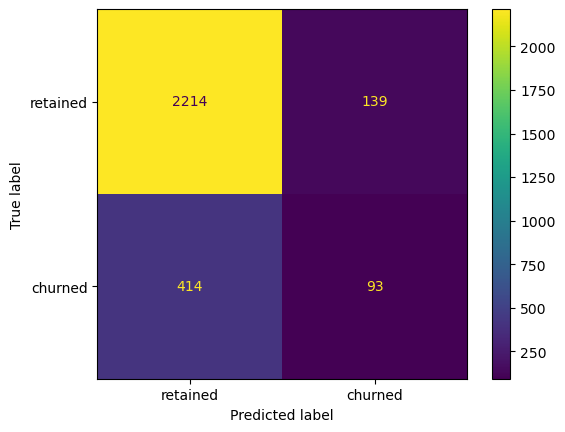

In [396]:
# Plot confusion matrix
cm = confusion_matrix(y_test, xgb_test_preds, labels=xgb_cv.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['retained', 'churned'])
disp.plot();

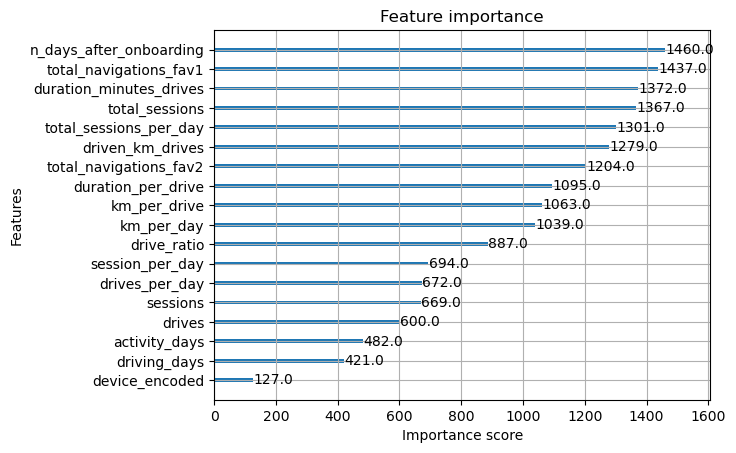

In [398]:
# Plot feature importance
plot_importance(xgb_cv.best_estimator_);

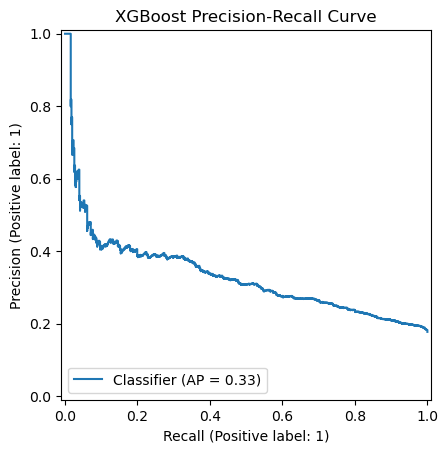

In [406]:
PrecisionRecallDisplay.from_predictions(y_test, xgb_test_probs)
plt.title('XGBoost Precision-Recall Curve')
plt.show()

In [400]:
# Get predicted probabilities
xgb_test_probs = xgb_cv.best_estimator_.predict_proba(X_test)[:, 1]

# Apply custom threshold
xgb_test_preds_04 = (xgb_test_probs >= 0.4).astype(int)

# Evaluate
print(classification_report(y_test, xgb_test_preds_04))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      2353
           1       0.38      0.25      0.30       507

    accuracy                           0.80      2860
   macro avg       0.62      0.58      0.59      2860
weighted avg       0.77      0.80      0.78      2860



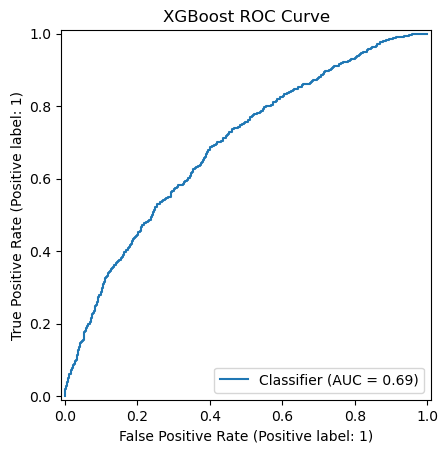

AUC: 0.689


In [404]:
RocCurveDisplay.from_predictions(y_test, xgb_test_probs)
plt.title('XGBoost ROC Curve')
plt.show()

print('AUC:', roc_auc_score(y_test, xgb_test_probs).round(3))

In [402]:
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_cv.best_estimator_, f)